# EDA Paris — Indicateur Qualité de Vie

Analyse exploratoire des données open data Paris & France.

| Signe | Dataset | Source |
|-------|---------|--------|
| ✅ | Îlots de fraîcheur (espaces verts) | Paris OpenData |
| ✅ | Arbres | Paris OpenData |
| ✅ | Îlots de fraîcheur (équipements) | Paris OpenData |
| ✅ | Qualité de l'air (NO2, PM2.5, PM10, O3) | data.gouv.fr |
| ✅ | Éligibilité fibre | data.gouv.fr |
| ❌ | Sanisettes publiques | Paris OpenData |
| ❌ | Comptages routiers permanents | Paris OpenData |
| ❌ | Chantiers à Paris | Paris OpenData |
| ❌ | Dans ma rue (anomalies) | Paris OpenData |
| ❌ | Zones touristiques | Paris OpenData |
| ❌ | Terrasses autorisées | Paris OpenData |

In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 20)

PARIS_API = 'https://parisdata.opendatasoft.com/api/explore/v2.1/catalog/datasets'
DATAGOUV_API = 'https://www.data.gouv.fr/api/1'
PAGE_SIZE = 100  # limite dure de l'API OpenDataSoft v2.1

def fetch_paris(dataset_id, max_records=500, **kwargs):
    """Fetch records via pagination automatique (max 100 records/page)."""
    all_records = []
    offset = 0
    total = None
    while True:
        params = {'limit': PAGE_SIZE, 'offset': offset, **kwargs}
        r = requests.get(f'{PARIS_API}/{dataset_id}/records', params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
        if total is None:
            total = data.get('total_count', 0)
        batch = data.get('results', [])
        if not batch:
            break
        all_records.extend(batch)
        offset += len(batch)
        if offset >= min(max_records, total):
            break
    df = pd.json_normalize(all_records)
    print(f'[{dataset_id}] {len(df)} / {total} lignes totales — {len(df.columns)} colonnes')
    return df

print('Librairies chargées. Pagination auto activée (100 records/page max).')

Librairies chargées. Pagination auto activée (100 records/page max).


## 1. ✅ Îlots de fraîcheur — Espaces verts frais

In [4]:
df_espaces_verts = fetch_paris('ilots-de-fraicheur-espaces-verts-frais', max_records=500)
df_espaces_verts.head(3)

[ilots-de-fraicheur-espaces-verts-frais] 500 / 986 lignes totales — 30 colonnes


,identifiant,nsq_espace_vert,nom,type,p_vegetation_h,proportion_vegetation_haute,adresse,arrondissement,statut_ouverture,ouvert_24h,canicule_ouverture,ouverture_estivale_nocturne,horaires_periode,horaires_lundi,horaires_mardi,horaires_mercredi,horaires_jeudi,horaires_vendredi,horaires_samedi,horaires_dimanche,categorie,proposition_usager,id_dicom,surf_veget_sup8m_2024,indice_veget_sup8m_2024,geo_shape.type,geo_shape.geometry.coordinates,geo_shape.geometry.type,geo_point_2d.lon,geo_point_2d.lat
0,ID1598,12950.0,JARDINIERES DU BOULEVARD BOURDON,Décorations sur la voie publique,0.400000,40.000000,2 BOULEVARD BOURDON,75004,None,Oui,Non,Non,None,None,None,None,None,None,None,None,Jardiniere,None,None,624.205223,0.400000,Feature,"[[[[2.3678529863576805, 48.851679100528116], [...",MultiPolygon,2.366824,48.849477
1,ID827,NaN,Jardin de la place Mohamed Bouazizi,Promenades ouvertes,0.700000,70.000000,place Mohamed Bouazizi,75014,None,Oui,Non,Non,None,None,None,None,None,None,None,None,None,None,None,120.179045,0.700000,Feature,"[[[2.3372394089128443, 48.825269770244844], [2...",Polygon,2.337597,48.824921
2,ID681,147.0,MAIL PIERRE DESPROGES DIT TROTTOIR PIERRE DESP...,Promenades ouvertes,0.685502,68.550155,143 RUE DE LA ROQUETTE,75011,None,Oui,Non,Non,None,None,None,None,None,None,None,None,Mail,None,None,522.406493,0.408195,Feature,"[[[[2.3843589417286357, 48.85882254062511], [2...",MultiPolygon,2.385182,48.859086


In [5]:
print('Colonnes:', df_espaces_verts.columns.tolist())
print('\nValeurs manquantes:')
print(df_espaces_verts.isnull().sum()[df_espaces_verts.isnull().sum() > 0])

Colonnes: ['identifiant', 'nsq_espace_vert', 'nom', 'type', 'p_vegetation_h', 'proportion_vegetation_haute', 'adresse', 'arrondissement', 'statut_ouverture', 'ouvert_24h', 'canicule_ouverture', 'ouverture_estivale_nocturne', 'horaires_periode', 'horaires_lundi', 'horaires_mardi', 'horaires_mercredi', 'horaires_jeudi', 'horaires_vendredi', 'horaires_samedi', 'horaires_dimanche', 'categorie', 'proposition_usager', 'id_dicom', 'surf_veget_sup8m_2024', 'indice_veget_sup8m_2024', 'geo_shape.type', 'geo_shape.geometry.coordinates', 'geo_shape.geometry.type', 'geo_point_2d.lon', 'geo_point_2d.lat']

Valeurs manquantes:
identifiant                 15
nsq_espace_vert             17
nom                          1
type                         2
p_vegetation_h              21
                          ... 
categorie                   14
proposition_usager         480
id_dicom                   140
surf_veget_sup8m_2024       36
indice_veget_sup8m_2024      1
Length: 25, dtype: int64


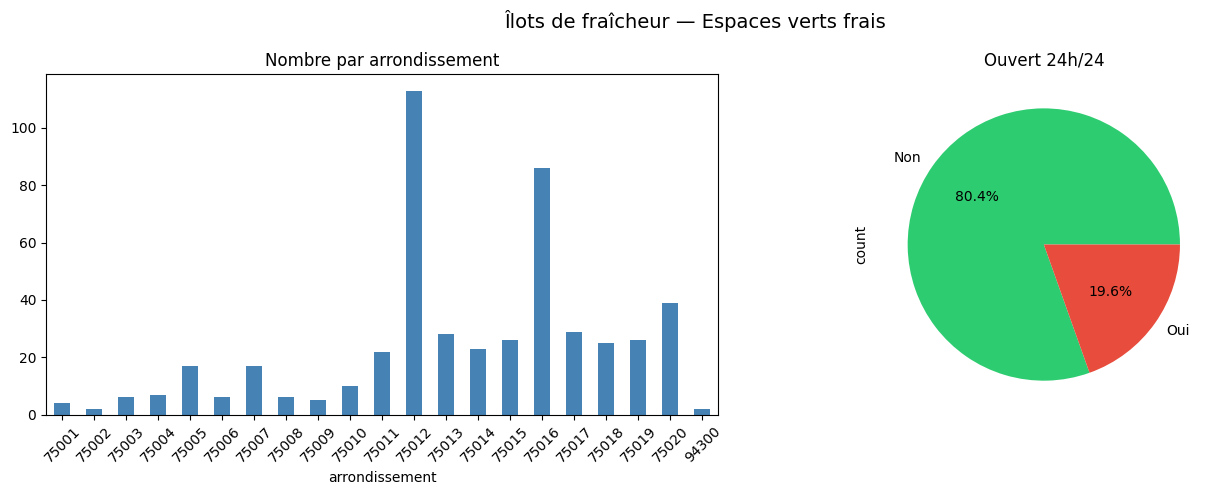

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Îlots de fraîcheur — Espaces verts frais', fontsize=14)

if 'arrondissement' in df_espaces_verts.columns:
    df_espaces_verts['arrondissement'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_title('Nombre par arrondissement')
    axes[0].tick_params(axis='x', rotation=45)

if 'ouvert_24h' in df_espaces_verts.columns:
    df_espaces_verts['ouvert_24h'].value_counts().plot(
        kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
    axes[1].set_title('Ouvert 24h/24')
elif 'statut_ouverture' in df_espaces_verts.columns:
    df_espaces_verts['statut_ouverture'].value_counts().plot(
        kind='pie', ax=axes[1], autopct='%1.1f%%')
    axes[1].set_title('Statut ouverture')

plt.tight_layout()
plt.show()

## 2. ✅ Arbres de Paris

In [7]:
# Dataset très large (~200k lignes) — échantillon 1000 pour l'EDA
df_arbres = fetch_paris('les-arbres', max_records=1000)
df_arbres.head(3)

[les-arbres] 1000 / 218055 lignes totales — 17 colonnes


,idbase,typeemplacement,domanialite,arrondissement,complementadresse,adresse,idemplacement,libellefrancais,genre,espece,varieteoucultivar,circonferenceencm,hauteurenm,stadedeveloppement,remarquable,geo_point_2d.lon,geo_point_2d.lat
0,126117,Arbre,Jardin,PARIS 20E ARRDT,None,JARDIN DE LA GARE DE CHARONNE / 59 BOULEVARD D...,000103036,Cèdre,Cedrus,atlantica,None,130,15,Adulte,NON,2.409514,48.851429
1,141306,Arbre,CIMETIERE,PARIS 15E ARRDT,None,CIMETIERE DE VAUGIRARD / AVENUE PRINCIPALE / D...,A14000011002,Erable,Acer,platanoides,None,75,8,Adulte,NON,2.284528,48.838323
2,250335,Arbre,Alignement,PARIS 19E ARRDT,None,RUE MANIN,001002013,Platane,Platanus,x hispanica,None,120,20,Adulte,NON,2.389925,48.883744


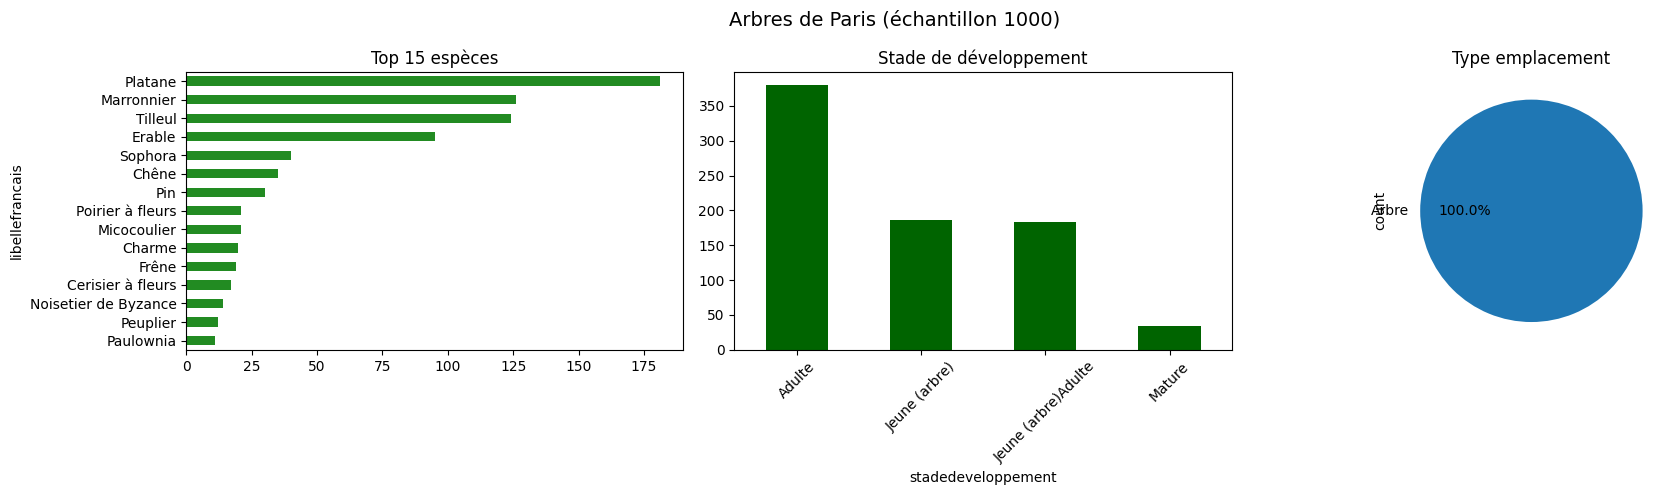

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Arbres de Paris (échantillon 1000)', fontsize=14)

if 'libellefrancais' in df_arbres.columns:
    df_arbres['libellefrancais'].value_counts().head(15).plot(
        kind='barh', ax=axes[0], color='forestgreen')
    axes[0].set_title('Top 15 espèces')
    axes[0].invert_yaxis()

if 'stadedeveloppement' in df_arbres.columns:
    df_arbres['stadedeveloppement'].value_counts().plot(
        kind='bar', ax=axes[1], color='darkgreen')
    axes[1].set_title('Stade de développement')
    axes[1].tick_params(axis='x', rotation=45)

if 'typeemplacement' in df_arbres.columns:
    df_arbres['typeemplacement'].value_counts().plot(
        kind='pie', ax=axes[2], autopct='%1.1f%%')
    axes[2].set_title('Type emplacement')

plt.tight_layout()
plt.show()

## 3. ✅ Îlots de fraîcheur — Équipements & Activités

In [9]:
df_equip = fetch_paris('ilots-de-fraicheur-equipements-activites', max_records=500)
df_equip.head(3)

[ilots-de-fraicheur-equipements-activites] 500 / 548 lignes totales — 22 colonnes


,identifiant,id_dicom,nom,type,payant,adresse,arrondissement,statut_ouverture,horaires_periode,horaires_lundi,horaires_mardi,horaires_mercredi,horaires_jeudi,horaires_vendredi,horaires_samedi,horaires_dimanche,proposition_usager,geo_shape.type,geo_shape.geometry.coordinates,geo_shape.geometry.type,geo_point_2d.lon,geo_point_2d.lat
0,LC35,19465,Eglise Saint-François de Sales,Lieux de culte,Non,15 RUE AMPERE,75017,None,"Les horaires étant susceptibles d'évoluer, mer...",None,None,None,None,None,None,None,Non,Feature,"[2.305013903156183, 48.884914071189634]",Point,2.305014,48.884914
1,OM50,None,KIOSQUE A MUSIQUE SQUARE JEAN CHERIOUX,Ombrière pérenne,Non,260 RUE DE VAUGIRARD,75015,None,Horaires d'ouverture de l'espace vert,None,None,None,None,None,None,None,Non,Feature,"[2.3005876556468787, 48.84024431176974]",Point,2.300588,48.840244
2,LC96,19484,Eglise Saint-Julien Le Pauvre,Lieux de culte,Non,1 RUE SAINT-JULIEN LE PAUVRE,75005,None,"Les horaires étant susceptibles d'évoluer, mer...",None,None,None,None,None,None,None,Non,Feature,"[2.3470575838867553, 48.8520087350826]",Point,2.347058,48.852009


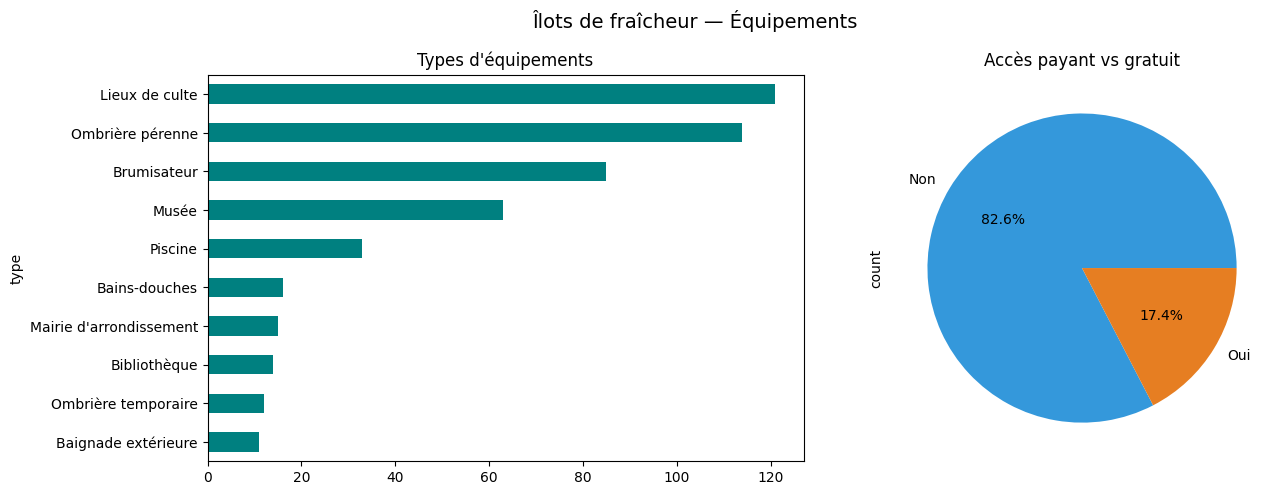

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Îlots de fraîcheur — Équipements', fontsize=14)

if 'type' in df_equip.columns:
    df_equip['type'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='teal')
    axes[0].set_title('Types d\'équipements')
    axes[0].invert_yaxis()

if 'payant' in df_equip.columns:
    df_equip['payant'].value_counts().plot(
        kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#3498db', '#e67e22'])
    axes[1].set_title('Accès payant vs gratuit')

plt.tight_layout()
plt.show()

## 4. ✅ Qualité de l'air — NO2, PM2.5, PM10, O3

In [11]:
DATASET_SLUG = 'qualite-de-lair-concentration-moyenne-no2-pm2-5-pm10-o3-a-partir-de-2015'
r = requests.get(f'{DATAGOUV_API}/datasets/{DATASET_SLUG}/', timeout=30)
r.raise_for_status()
dataset_info = r.json()
resources = dataset_info.get('resources', [])
print('Titre:', dataset_info.get('title'))
print(f'{len(resources)} ressource(s):')
for res in resources[:5]:
    print(f'  - {res.get("title")} | {res.get("format")} | {res.get("url", "")[:80]}')

Titre: Qualité de l'air - Concentration moyenne - NO2 - PM2.5 - PM10 - O3 à partir de 2015
2 ressource(s):
  - qualite-de-lair-concentration-moyenne-no2-pm25-pm10-o3-a-partir-de-2015.csv | csv | https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/qualite-de-lair-conc
  - qualite-de-lair-concentration-moyenne-no2-pm25-pm10-o3-a-partir-de-2015.json | json | https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/qualite-de-lair-conc


In [12]:
csv_resources = [res for res in resources if res.get('format', '').upper() in ('CSV', 'JSON')]
df_air = None
for res in csv_resources[:3]:
    try:
        url = res.get('url')
        if url:
            print(f'Tentative: {res.get("title")} ({url[:60]}...)')
            df_air = pd.read_csv(url, sep=None, engine='python', nrows=5000)
            print(f'  → Chargé: {df_air.shape}')
            break
    except Exception as e:
        print(f'  → Erreur: {e}')

if df_air is not None:
    display(df_air.head(3))

Tentative: qualite-de-lair-concentration-moyenne-no2-pm25-pm10-o3-a-partir-de-2015.csv (https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/...)
  → Chargé: (10, 27)


,﻿Année,NO2 Réglementaire,NO2 Recommandation OMS,NO2 Fond-urbain Moyenne annuelle - Airparif,Variation NO2 Fond-urbain - Moyenne-annuelle,NO2 Proximité trafic BP Est - Moyenne annuelle - Airparif,Variation NO2 Proximite-trafic-BP Est - Moyenne annuelle,NO2 Proximité trafic IntraM - Moyenne annuelle - Airparif,Variation NO2 Proximite trafic-intraM - Moyenne annuelle,PM2-5 Réglementaire,PM2-5 Recommandation OMS,PM2-5 Fond urbain Moyenne annuelle - Airparif,Variation PM2-5 Fond-urbain - Moyenne annuelle,PM2-5 Proximité trafic BP Est - Moyenne annuelle - Airparif,Variation PM2-5 Proximite trafic-BP Est - Moyenne annuelle,PM10 Réglementaire,PM10 Recommandation OMS,PM10 Fond urbain Moyenne annuelle - Airparif,Variation PM10 Fond urbain - Moyenne-annuelle,PM10 Proximité trafic BP Est - Moyenne annuelle - Airparif,Variation PM10 Proximite-trafic-BP Est - Moyenne annuelle,PM10 Proximité trafic IntraM - Moyenne annuelle - Airparif,Variation PM10 Proximite trafic-intraM - Moyenne annuelle,O3 Réglementaire,O3 Recommandation OMS,O3 Moyenne annuelle - Airparif,Variation O3 - Moyenne_annuelle
0,2017,40,40,35,-2.857143,65,-1.538462,59.0,-3.389831,25,10,14,0.0,16.0,-12.500000,40,20,20,-10.000000,29.0,-6.896552,31.0,0.000000,120.0,160.0,38.0,2.631579
1,2020,40,40,22,-36.363636,49,-24.489796,35.0,-40.000000,25,10,10,-30.0,14.0,-14.285714,40,20,18,-5.555556,26.0,-11.538462,27.0,-7.407407,120.0,160.0,47.0,8.510638
2,2022,40,10,24,-4.166667,52,-1.923077,38.0,2.631579,25,5,12,0.0,15.0,0.000000,40,15,20,5.000000,29.0,0.000000,24.0,-4.166667,120.0,100.0,51.0,9.803922


Colonnes polluants: ['NO2 Réglementaire', 'NO2 Recommandation OMS', 'NO2 Fond-urbain Moyenne annuelle - Airparif', 'Variation NO2 Fond-urbain - Moyenne-annuelle', 'NO2 Proximité trafic BP Est -  Moyenne annuelle - Airparif', 'Variation NO2 Proximite-trafic-BP Est - Moyenne annuelle', 'NO2 Proximité trafic IntraM -  Moyenne annuelle - Airparif', 'Variation NO2 Proximite trafic-intraM - Moyenne annuelle', 'PM2-5 Réglementaire', 'PM2-5 Recommandation OMS', 'PM2-5 Fond urbain Moyenne annuelle - Airparif', 'Variation PM2-5 Fond-urbain - Moyenne annuelle', 'PM2-5 Proximité trafic BP Est -  Moyenne annuelle - Airparif', 'Variation PM2-5 Proximite trafic-BP Est - Moyenne annuelle', 'PM10 Réglementaire', 'PM10 Recommandation OMS', 'PM10 Fond urbain Moyenne annuelle - Airparif', 'Variation PM10 Fond urbain - Moyenne-annuelle', 'PM10 Proximité trafic BP Est -  Moyenne annuelle - Airparif', 'Variation PM10 Proximite-trafic-BP Est - Moyenne annuelle', 'PM10  Proximité trafic IntraM -  Moyenne annue

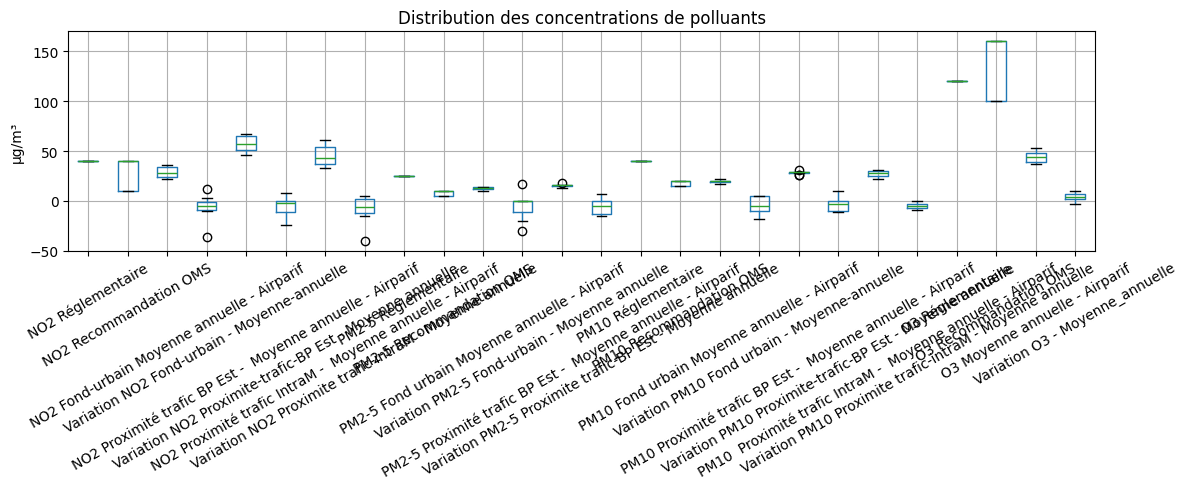

In [13]:
if df_air is not None:
    polluants = [c for c in df_air.columns if any(p in c.upper() for p in ['NO2', 'PM', 'O3'])]
    print('Colonnes polluants:', polluants)
    if polluants:
        fig, ax = plt.subplots(figsize=(12, 5))
        df_air[polluants].dropna().boxplot(ax=ax)
        ax.set_title('Distribution des concentrations de polluants')
        ax.set_ylabel('µg/m³')
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

## 5. ✅ Éligibilité Fibre — Ma Connexion Internet

In [14]:
r2 = requests.get(f'{DATAGOUV_API}/datasets/ma-connexion-internet/', timeout=30)
r2.raise_for_status()
fibre_info = r2.json()
fibre_resources = fibre_info.get('resources', [])
print('Titre:', fibre_info.get('title'))
print(f'{len(fibre_resources)} ressource(s):')
for res in fibre_resources[:5]:
    print(f'  - {res.get("title")} | {res.get("format")} | {res.get("url", "")[:80]}')

Titre: Ma connexion internet
11 ressource(s):
  - Tableau de bord - départements, régions, France entière | xlsx | https://static.data.gouv.fr/resources/ma-connexion-internet/20240409-151629/tabl
  - Tableau de bord - communes | xlsx | https://static.data.gouv.fr/resources/ma-connexion-internet/20240409-151647/tabl
  - Base immeuble | csv | https://data.arcep.fr/fixe/maconnexioninternet/base_imb/last/
  - Table d'éligibilité | csv | https://data.arcep.fr/fixe/maconnexioninternet/eligibilite/last/
  - Fermeture cuivre | csv | https://data.arcep.fr/fixe/maconnexioninternet/fermeture_cuivre/last/


In [15]:
csv_fibre = [res for res in fibre_resources if res.get('format', '').upper() in ('CSV', 'JSON')]
df_fibre = None
for res in csv_fibre[:3]:
    try:
        url = res.get('url')
        if url:
            print(f'Tentative: {res.get("title")}')
            df_fibre = pd.read_csv(url, sep=None, engine='python', nrows=5000)
            print(f'  → Chargé: {df_fibre.shape}')
            break
    except Exception as e:
        print(f'  → Erreur: {e}')

if df_fibre is not None:
    display(df_fibre.head(3))
    print('\nColonnes:', df_fibre.columns.tolist())

Tentative: Base immeuble
  → Erreur: Expected 2 fields in line 7, saw 3
Tentative: Table d'éligibilité
  → Erreur: Expected 2 fields in line 7, saw 3
Tentative: Fermeture cuivre
  → Erreur: Expected 2 fields in line 7, saw 3


## 6. ❌ Sanisettes publiques

In [16]:
df_sanisettes = fetch_paris('sanisettesparis', max_records=500)
df_sanisettes.head(3)

[sanisettesparis] 500 / 617 lignes totales — 13 colonnes


,type,statut,adresse,arrondissement,horaire,acces_pmr,relais_bebe,url_fiche_equipement,geo_shape.type,geo_shape.geometry.coordinates,geo_shape.geometry.type,geo_point_2d.lon,geo_point_2d.lat
0,WC,Hors service,2 quai de l archeveche,75004,Horaires du parc,Non,Non,https://www.paris.fr/lieux/square-jean-xxiii-35,Feature,"[2.351064327131835, 48.85284931542226]",Point,2.351064,48.852849
1,Sanisette,En service,36 bd de sebastopol,75004,06h00 - 22h00,Oui,Non,None,Feature,"[2.35003599988823, 48.86155799965233]",Point,2.350036,48.861558
2,Sanisette,En service,10 avenue de l observatoire,75006,Horaires du parc,Oui,Non,https://www.paris.fr/lieux/jardin-des-grands-e...,Feature,"[2.337260643906852, 48.84221838628398]",Point,2.337261,48.842218


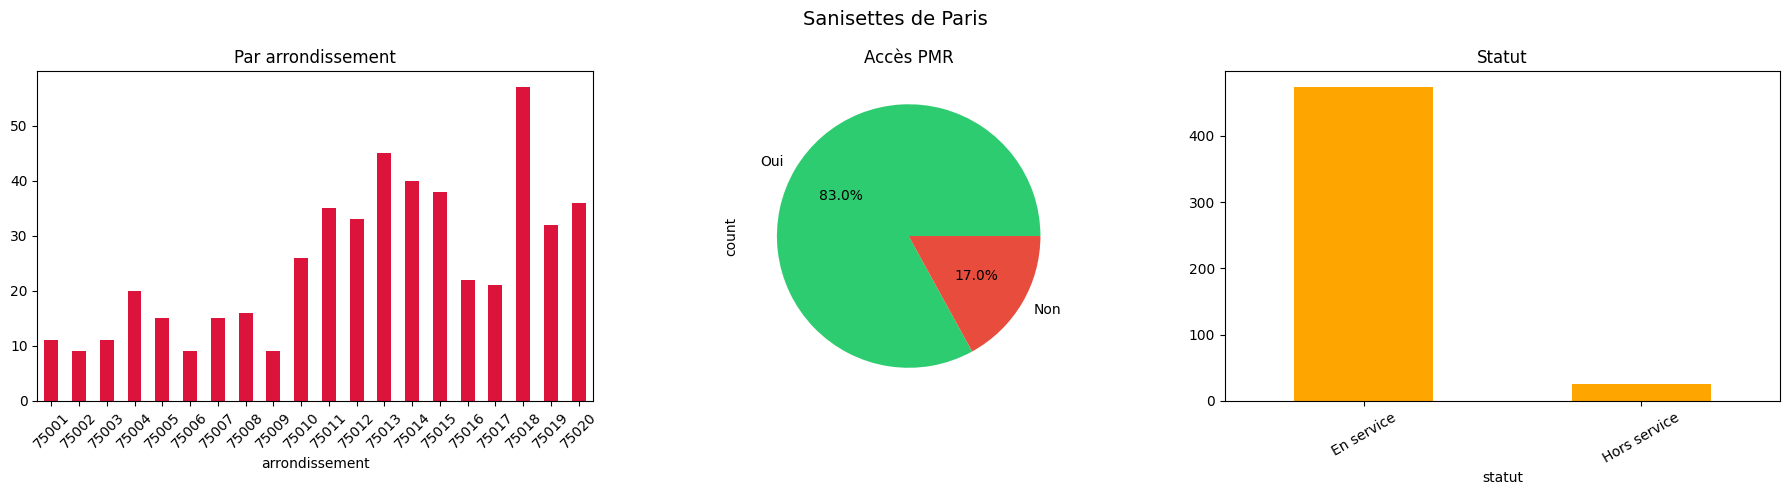

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sanisettes de Paris', fontsize=14)

if 'arrondissement' in df_sanisettes.columns:
    df_sanisettes['arrondissement'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0], color='crimson')
    axes[0].set_title('Par arrondissement')
    axes[0].tick_params(axis='x', rotation=45)

if 'acces_pmr' in df_sanisettes.columns:
    df_sanisettes['acces_pmr'].value_counts().plot(
        kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
    axes[1].set_title('Accès PMR')

if 'statut' in df_sanisettes.columns:
    df_sanisettes['statut'].value_counts().plot(kind='bar', ax=axes[2], color='orange')
    axes[2].set_title('Statut')
    axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 7. ❌ Comptages routiers permanents

In [18]:
df_trafic = fetch_paris('comptages-routiers-permanents', max_records=200)
df_trafic.head(3)

[comptages-routiers-permanents] 200 / 28278870 lignes totales — 18 colonnes


,iu_ac,libelle,t_1h,q,k,etat_trafic,iu_nd_amont,libelle_nd_amont,iu_nd_aval,libelle_nd_aval,etat_barre,date_debut,date_fin,geo_point_2d.lon,geo_point_2d.lat,geo_shape.type,geo_shape.geometry.coordinates,geo_shape.geometry.type
0,5354,PE_Leon_Frapie,2025-04-03T22:00:00+00:00,3816.0,7.70,Fluide,2830,PE_Frapie,2831,SE_Lilas,Ouvert,1996-10-30,2023-01-01,2.411378,48.874088,Feature,"[[2.4126608377155656, 48.8725149980057], [2.41...",LineString
1,5355,PI_Leon_Frapie,2025-04-03T20:00:00+00:00,4503.0,11.85,Fluide,781,AI_Lilas,2832,PI_Frapie,Ouvert,1996-10-30,2023-01-01,2.411160,48.873997,Feature,"[[2.4098995276140305, 48.875653611124584], [2....",LineString
2,5355,PI_Leon_Frapie,2025-04-03T21:00:00+00:00,4086.0,10.60,Fluide,781,AI_Lilas,2832,PI_Frapie,Ouvert,1996-10-30,2023-01-01,2.411160,48.873997,Feature,"[[2.4098995276140305, 48.875653611124584], [2....",LineString


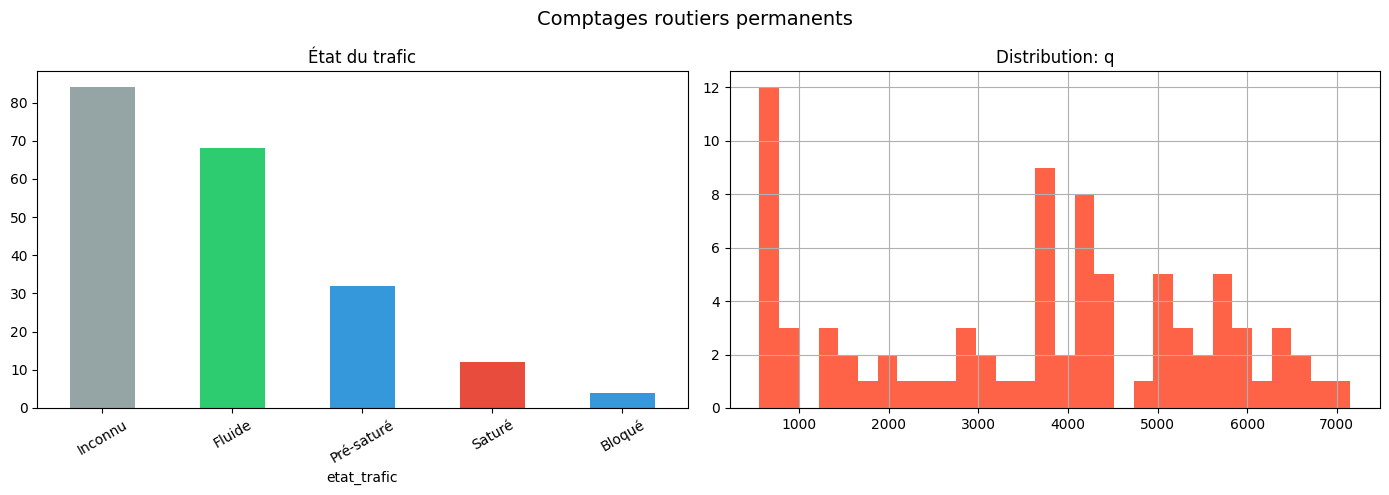

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comptages routiers permanents', fontsize=14)

if 'etat_trafic' in df_trafic.columns:
    counts = df_trafic['etat_trafic'].value_counts()
    color_map = {'Fluide': '#2ecc71', 'Dense': '#e67e22', 'Saturé': '#e74c3c', 'Inconnu': '#95a5a6'}
    bar_colors = [color_map.get(v, '#3498db') for v in counts.index]
    counts.plot(kind='bar', ax=axes[0], color=bar_colors)
    axes[0].set_title('État du trafic')
    axes[0].tick_params(axis='x', rotation=30)

num_cols = df_trafic.select_dtypes(include='number').columns.tolist()
if num_cols:
    df_trafic[num_cols[0]].dropna().hist(bins=30, ax=axes[1], color='tomato')
    axes[1].set_title(f'Distribution: {num_cols[0]}')

plt.tight_layout()
plt.show()

## 8. ❌ Chantiers à Paris

In [20]:
df_chantiers = fetch_paris('chantiers-a-paris', max_records=500)
df_chantiers.head(3)

[chantiers-a-paris] 500 / 5412 lignes totales — 17 colonnes


,num_emprise,cp_arrondissement,date_debut,date_fin,chantier_categorie,moa_principal,surface,chantier_synthese,localisation_detail,localisation_stationnement,demande_cite_id,chantier_cite_id,geo_shape.type,geo_shape.geometry.coordinates,geo_shape.geometry.type,geo_point_2d.lon,geo_point_2d.lat
0,EC499145,75012,2026-05-04,2026-07-01,Tiers (travaux sur bâtiment),Propriétés - Co-propriétés publiques et privées,8.87,Construction ou réhabilitation d’immeuble,[EMPRISE_CHAUSSEE],[ZONE_LIVRAISON],949961,324598,Feature,"[[[2.3722197533254534, 48.85229175348467], [2....",Polygon,2.372256,48.852290
1,EC482957,75008,2026-03-02,2026-06-01,Tiers (travaux sur bâtiment),Propriétés - Co-propriétés publiques et privées,10.98,Construction ou réhabilitation d’immeuble,[EMPRISE_CHAUSSEE],[STATIONNEMENT_PAYANT],937144,314312,Feature,"[[[2.3178310307189616, 48.873387644098656], [2...",Polygon,2.317837,48.873411
2,EC491167,75015,2026-03-23,2026-06-30,Tiers (travaux sur bâtiment),Propriétés - Co-propriétés publiques et privées,18.32,Construction ou réhabilitation d’immeuble,[EMPRISE_CHAUSSEE],[STATIONNEMENT_PAYANT],943809,319688,Feature,"[[[2.306010397173434, 48.84081239065623], [2.3...",Polygon,2.306035,48.840769


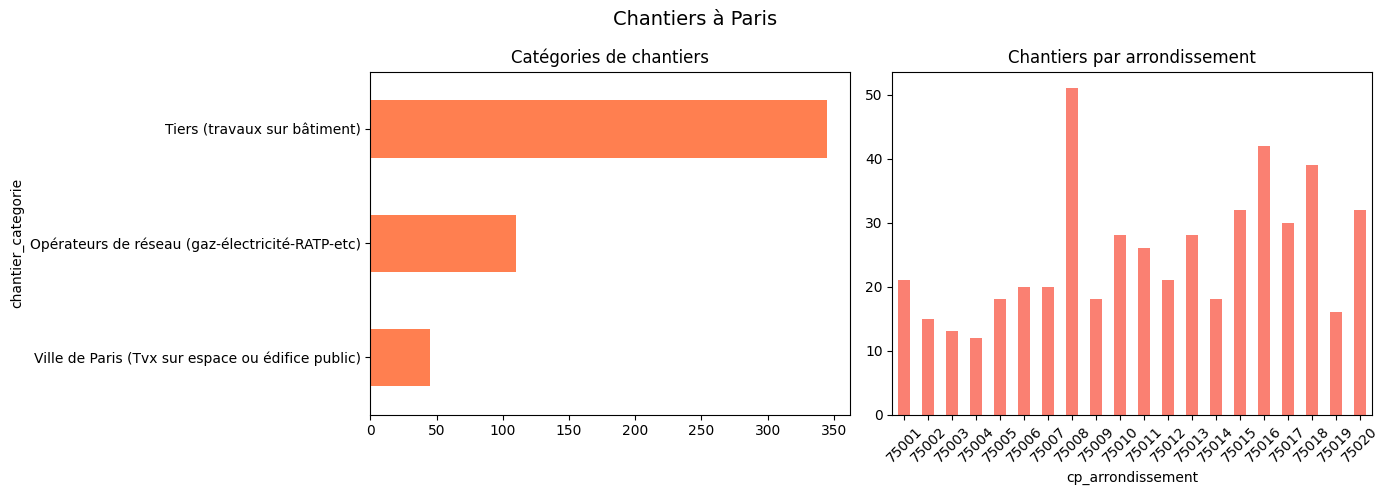

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chantiers à Paris', fontsize=14)

if 'chantier_categorie' in df_chantiers.columns:
    df_chantiers['chantier_categorie'].value_counts().head(10).plot(
        kind='barh', ax=axes[0], color='coral')
    axes[0].set_title('Catégories de chantiers')
    axes[0].invert_yaxis()

if 'cp_arrondissement' in df_chantiers.columns:
    df_chantiers['cp_arrondissement'].value_counts().sort_index().head(20).plot(
        kind='bar', ax=axes[1], color='salmon')
    axes[1].set_title('Chantiers par arrondissement')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 9. ❌ Dans ma rue — Anomalies signalées

In [22]:
df_anomalies = fetch_paris('dans-ma-rue', max_records=500)
df_anomalies.head(3)

[dans-ma-rue] 500 / 1184561 lignes totales — 20 colonnes


,numero,type,soustype,adresse,code_postal,ville,arrondissement,conseilquartier,datedecl,anneedecl,moisdecl,prefixe,intervenant,id_dmr,mois_annee_decla,geo_shape.type,geo_shape.geometry.coordinates,geo_shape.geometry.type,geo_point_2d.lon,geo_point_2d.lat
0,80764,"Autos, motos, vélos, trottinettes...",[] Automobile ou autre véhicule motorisé en st...,"28 Rue Jean Rey, 75015 PARIS",75015,Paris 15,15,DUPLEIX - LA MOTTE PICQUET,2025-03-15,2025,3,IOS application,DPMP-Divisions,A2025C080764,2025-03,Feature,"[2.2932195997139626, 48.85589999882184]",Point,2.293220,48.855900
1,34275,Propreté,[] Patrouille propreté Fonctionnelle,"50 Boulevard de Belleville, 75020 PARIS",75020,Paris 20,20,BELLEVILLE,2025-08-08,2025,8,Android,DPE-STPP-Fonctionnelle,G2025H034275,2025-08,Feature,"[2.38090999985394, 48.86890999901846]",Point,2.380910,48.868910
2,118900,Objets abandonnés,Autres objets encombrants abandonnés,"18 Rue de Torcy, 75018 PARIS",75018,Paris 18,18,LA CHAPELLE - MARX DORMOY,2025-04-22,2025,4,Android,DPE-STPP-DT,G2025D118900,2025-04,Feature,"[2.363483000059108, 48.89131499906259]",Point,2.363483,48.891315


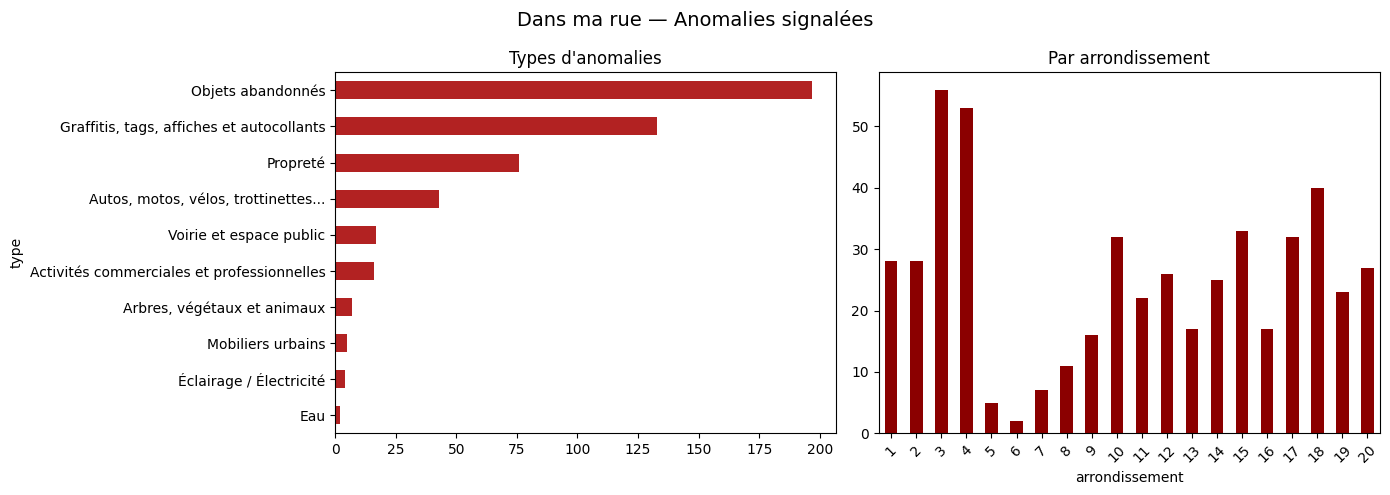

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dans ma rue — Anomalies signalées', fontsize=14)

if 'type' in df_anomalies.columns:
    df_anomalies['type'].value_counts().head(12).plot(
        kind='barh', ax=axes[0], color='firebrick')
    axes[0].set_title('Types d\'anomalies')
    axes[0].invert_yaxis()

if 'arrondissement' in df_anomalies.columns:
    df_anomalies['arrondissement'].value_counts().sort_index().plot(
        kind='bar', ax=axes[1], color='darkred')
    axes[1].set_title('Par arrondissement')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. ❌ Zones touristiques internationales

In [24]:
df_tourisme = fetch_paris('zones-touristiques-internationales', max_records=100)
print('Colonnes:', df_tourisme.columns.tolist())
if 'name' in df_tourisme.columns:
    print('\nZones:', df_tourisme['name'].tolist())

[zones-touristiques-internationales] 12 / 12 lignes totales — 15 colonnes
Colonnes: ['name', 'type', '_timestamp', '_uid', 'source', '_user', '_version', 'boundary', '_changeset', '_id', 'geo_point_2d.lon', 'geo_point_2d.lat', 'geo_shape.type', 'geo_shape.geometry.coordinates', 'geo_shape.geometry.type']

Zones: ['Saint-Honoré - Vendôme', 'Montmartre', 'Olympiades', 'Le Marais', 'Rennes - Saint-Sulpice', 'Maillot-Ternes', 'Saint-Germain', 'Haussmann', 'Les Halles', 'Champs-Elysées Montaigne', 'Saint-Emilion Bibliothèque', 'Beaugrenelle']


## 11. ❌ Terrasses autorisées

In [25]:
df_terrasses = fetch_paris('terrasses-autorisations', max_records=500)
df_terrasses.head(3)

[terrasses-autorisations] 500 / 23877 lignes totales — 15 colonnes


,typologie,adresse,arrondissement,nom_enseigne,nom_societe,siret,longueur,largeur,periode_installation,lien_affichette,geo_shape.type,geo_shape.geometry.coordinates,geo_shape.geometry.type,geo_point_2d.lon,geo_point_2d.lat
0,CONTRE TERRASSE ESTIVALE SUR TROTTOIR FACE À L...,125 AVENUE DE CHOISY,75013,LE MANDARIN DE CHOISY,None,32187797900013,3.7,2.6,None,https://eudonet-terrasses.apps.paris.fr/xrm/at...,Feature,"[2.3599567229981195, 48.82601931373037]",Point,2.359957,48.826019
1,TERRASSE ESTIVALE SUR TROTTOIR FACE À LA DEVAN...,49 RUE DE DOUAI,75009,PERLOUSE,None,83420711000018,7.5,0.5,None,None,Feature,"[2.3308403930304826, 48.88312011089001]",Point,2.330840,48.883120
2,CONTRE TERRASSE ESTIVALE SUR TROTTOIR FACE À L...,234 RUE DE BERCY,75012,HOTEL SLEEPING BELLE,None,39852698800082,7.2,0.6,None,None,Feature,"[2.3698120062463617, 48.846622391569575]",Point,2.369812,48.846622


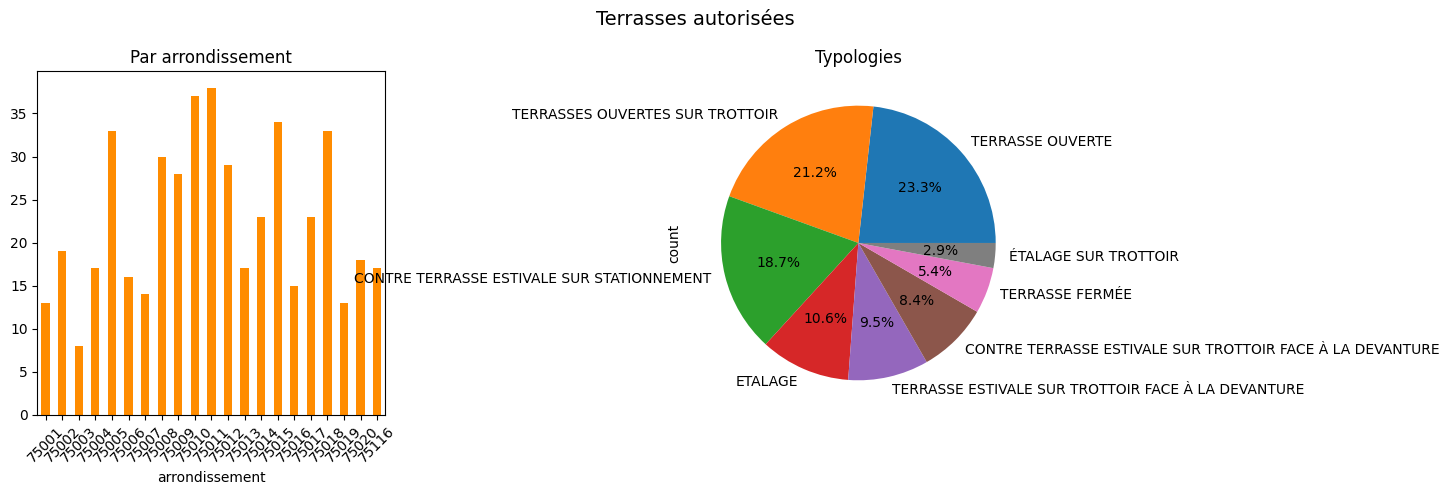

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Terrasses autorisées', fontsize=14)

if 'arrondissement' in df_terrasses.columns:
    df_terrasses['arrondissement'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0], color='darkorange')
    axes[0].set_title('Par arrondissement')
    axes[0].tick_params(axis='x', rotation=45)

if 'typologie' in df_terrasses.columns:
    df_terrasses['typologie'].value_counts().head(8).plot(
        kind='pie', ax=axes[1], autopct='%1.1f%%')
    axes[1].set_title('Typologies')

plt.tight_layout()
plt.show()

## 12. Carte interactive Paris — Synthèse

In [27]:
m = folium.Map(location=[48.8566, 2.3522], zoom_start=12, tiles='CartoDB positron')

def find_geo_cols(df):
    lats = [c for c in df.columns if 'lat' in c.lower()]
    lons = [c for c in df.columns if any(x in c.lower() for x in ['lon', 'lng', 'long'])]
    return lats, lons

def add_points(df, color, label):
    lats, lons = find_geo_cols(df)
    if not lats or not lons:
        print(f'  Pas de colonnes geo pour: {label}')
        return
    count = 0
    for _, row in df.iterrows():
        try:
            lat, lon = float(row[lats[0]]), float(row[lons[0]])
            if -90 <= lat <= 90 and -180 <= lon <= 180:
                folium.CircleMarker([lat, lon], radius=4, color=color,
                    fill=True, fill_opacity=0.7, tooltip=label).add_to(m)
                count += 1
        except (ValueError, TypeError):
            continue
    print(f'  {label}: {count} points')

layers = [
    (df_espaces_verts, 'green', 'Espace vert'),
    (df_sanisettes, 'red', 'Sanisette'),
    (df_terrasses, 'orange', 'Terrasse'),
    (df_anomalies, 'darkred', 'Anomalie'),
    (df_chantiers, 'black', 'Chantier'),
]
print('Ajout des couches...')
for df, color, label in layers:
    add_points(df, color, label)

m

Ajout des couches...
  Espace vert: 500 points
  Sanisette: 500 points
  Terrasse: 0 points
  Anomalie: 500 points
  Chantier: 500 points


## 13. Résumé — Tableau de bord

In [1]:
summary = pd.DataFrame([
    {'Dataset': 'Îlots fraîcheur (espaces verts)', 'Signe': '✅', 'Lignes': len(df_espaces_verts), 'Source': 'Paris OpenData'},
    {'Dataset': 'Arbres (échantillon)', 'Signe': '✅', 'Lignes': len(df_arbres), 'Source': 'Paris OpenData'},
    {'Dataset': 'Îlots fraîcheur (équipements)', 'Signe': '✅', 'Lignes': len(df_equip), 'Source': 'Paris OpenData'},
    {'Dataset': 'Qualité de l\'air', 'Signe': '✅', 'Lignes': len(df_air) if df_air is not None else 0, 'Source': 'data.gouv.fr'},
    {'Dataset': 'Éligibilité fibre', 'Signe': '✅', 'Lignes': len(df_fibre) if df_fibre is not None else 0, 'Source': 'data.gouv.fr'},
    {'Dataset': 'Sanisettes', 'Signe': '❌', 'Lignes': len(df_sanisettes), 'Source': 'Paris OpenData'},
    {'Dataset': 'Comptages routiers', 'Signe': '❌', 'Lignes': len(df_trafic), 'Source': 'Paris OpenData'},
    {'Dataset': 'Chantiers', 'Signe': '❌', 'Lignes': len(df_chantiers), 'Source': 'Paris OpenData'},
    {'Dataset': 'Dans ma rue (anomalies)', 'Signe': '❌', 'Lignes': len(df_anomalies), 'Source': 'Paris OpenData'},
    {'Dataset': 'Zones touristiques', 'Signe': '❌', 'Lignes': len(df_tourisme), 'Source': 'Paris OpenData'},
    {'Dataset': 'Terrasses autorisées', 'Signe': '❌', 'Lignes': len(df_terrasses), 'Source': 'Paris OpenData'},
])

summary.style.set_caption('Récapitulatif des 11 datasets').background_gradient(
    subset=['Lignes'], cmap='Blues')

NameError: name 'pd' is not defined